# Day 4 - Introduction to Deep Learning

Data Science for Life Scientists

Today we will build a simple neural network using **PyTorch**. We will use the same kind of Cell Painting profiles introduced earlier in the course: each compound is represented by image-derived morphology features, and the model learns to predict one ToxCast cell-based assay endpoint.

The goal is not to build a state-of-the-art model. The goal is to practise a clean deep-learning protocol: prepare data without leakage, split into training / validation / test datasets, train a neural network, monitor training and validation loss, experiment with parameters, and evaluate once on an independent held-out test set.

## Topics

- Build a simple neural network using PyTorch
- Convert tabular Cell Painting profiles into tensors
- Train with mini-batches using `Dataset` and `DataLoader`
- Experiment with dropout, batch size, number of epochs, learning rate, hidden-layer size, and loss functions
- Evaluate models using training and validation loss curves
- Choose model settings using validation data only
- Test the selected model on an independent held-out test dataset

## Learning outcomes

By the end of this notebook, you should be able to:

- Describe the basic parts of a deep-learning workflow
- Build and train a small feed-forward neural network in PyTorch
- Explain how dropout, batch size, training iterations, and loss functions can change performance
- Use training and validation loss to diagnose overfitting and underfitting
- Evaluate a trained neural network on an independent test dataset
- Connect deep-learning workflows to bioimaging data analysis

## Notebook workflow

1. Load Cell Painting profiles, compound metadata, and ToxCast labels.
2. Choose one biological activity endpoint to predict.
3. Make training, validation, and independent test splits.
4. Select and scale features using the training set only.
5. Convert arrays into PyTorch tensors and data loaders.
6. Define a simple neural network.
7. Train the network and monitor training / validation loss.
8. Experiment with dropout, batch size, epochs, and loss functions.
9. Select the best settings using validation performance.
10. Evaluate once on the held-out test set.

## 1. Setup

This notebook uses **PyTorch** for the neural network and scikit-learn for splitting, preprocessing, and evaluation metrics.

Useful documentation links:

- PyTorch tensors: [`torch.tensor`](https://pytorch.org/docs/stable/generated/torch.tensor.html)
- Neural network modules: [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)
- Layers: [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html), [`torch.nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html), [`torch.nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
- Loss functions: [`torch.nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)
- Optimisers: [`torch.optim.Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html)
- Data loading: [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset), [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)
- scikit-learn splitting: [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- scikit-learn scaling: [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

In [87]:
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [88]:

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "PyTorch is required for this notebook. Install the course requirements with: "
        "uv pip install -r requirements.txt"
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
MODEL_FAMILY = "PyTorch neural network"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda") # CUDA is available, so we use it for training with GPU.
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps") # MPS is available, so we use it for training with Apple Silicon GPU.
else:
    DEVICE = torch.device("cpu") # No GPU available, so we use the CPU.

print(f"Model implementation: {MODEL_FAMILY}")
print(f"PyTorch version: {torch.__version__}")
print(f"Training device: {DEVICE}")

Model implementation: PyTorch neural network
PyTorch version: 2.12.0
Training device: mps


## 2. Load and merge the datasets

We will use three tables, following the same biological setup as the classical machine-learning protocol:

- `df_cell_painting`: Cell Painting profiles for reference compounds.
- `df_compounds_infos`: compound metadata.
- `df_toxcast_cellbased`: ToxCast cell-based binary activity labels.

The Cell Painting profiles are not raw pixels. They are measurements extracted from bioimages, such as morphology, intensity, and texture features. A simple neural network can still be useful here because it can learn nonlinear combinations of these image-derived measurements.

The merge path is:

`Metadata_compound` -> `PREFERRED_NAME` -> `OASIS_ID` -> ToxCast assay labels

In [89]:
# Paths are written relative to this notebook folder.
DATA_DIR = Path("../../inputs")

df_cell_painting = pd.read_parquet(DATA_DIR / "level6_axiom_selected_features.parquet")
df_toxcast_cytotox = pd.read_parquet(DATA_DIR / "toxcast_cytotox_binary.parquet")
df_compounds_infos = pd.read_csv(DATA_DIR / "v5_oasis_03Sept2024_simple.csv")

print(f"Cell Painting profiles: {df_cell_painting.shape}")
print(f"ToxCast cytotoxic labels: {df_toxcast_cytotox.shape}")
print(f"Compound metadata: {df_compounds_infos.shape}")

Cell Painting profiles: (1086, 4439)
ToxCast cytotoxic labels: (963, 39)
Compound metadata: (1494, 20)


In [90]:
# A few compound names are repeated in the metadata table. Dropping duplicates prevents
# one Cell Painting row from expanding into multiple rows during the merge.
df_compounds_infos_unique = df_compounds_infos.drop_duplicates(subset="PREFERRED_NAME").copy()

df_cell_painting_compounds_infos = df_cell_painting.merge(
    df_compounds_infos_unique,
    how="left",
    left_on="Metadata_compound",
    right_on="PREFERRED_NAME",
    validate="many_to_one",
)

df_dl = df_cell_painting_compounds_infos.merge(
    df_toxcast_cytotox,
    how="inner",
    on="OASIS_ID",
    validate="many_to_one",
)

print(f"Cell Painting compounds: {len(df_cell_painting):,}")
print(f"Cell Painting compounds with OASIS_ID: {df_cell_painting_compounds_infos['OASIS_ID'].notna().sum():,}")
print(f"Compounds merged with ToxCast cell-based labels: {len(df_dl):,}")

df_dl[["Metadata_compound", "PREFERRED_NAME", "OASIS_ID"]].head()

Cell Painting compounds: 1,086
Cell Painting compounds with OASIS_ID: 791
Compounds merged with ToxCast cell-based labels: 551


,Metadata_compound,PREFERRED_NAME,OASIS_ID
0,"1,4-Dibromobenzene","1,4-Dibromobenzene",OASIS548
1,"1,4-Dichlorobenzene","1,4-Dichlorobenzene",OASIS292
2,"1,6-Dichlorohexane","1,6-Dichlorohexane",OASIS287
3,1-Naphthaleneacetic acid,1-Naphthaleneacetic acid,OASIS370
4,"2,6-Diaminopyridine","2,6-Diaminopyridine",OASIS381


## 3. Choose the assay / mode of action to predict

A supervised neural network needs an input `X` and a target `y`.

- `X`: Cell Painting features extracted from microscopy images.
- `y`: one binary ToxCast endpoint, where `1` means active and `0` means inactive.

For a first neural-network exercise, choose a target with enough examples in both classes. Deep learning models can overfit quickly when the dataset is small or highly imbalanced.

In [91]:
feature_cols = [col for col in df_dl.columns if col.startswith("Feature_")]
toxcast_assay_cols = [col for col in df_toxcast_cytotox.columns if col != "OASIS_ID"]

target_summary = df_dl[toxcast_assay_cols].agg(["sum", "count"]).T
target_summary = target_summary.rename(columns={"sum": "n_active", "count": "n_tested"})
target_summary["n_inactive"] = target_summary["n_tested"] - target_summary["n_active"]
target_summary["active_fraction"] = target_summary["n_active"] / target_summary["n_tested"]

eligible_targets = target_summary.query("n_active >= 25 and n_inactive >= 25").sort_values(
    ["active_fraction", "n_tested"], ascending=[False, False]
)

print(f"Number of Cell Painting features: {len(feature_cols):,}")
print(f"Number of possible ToxCast cytotoxic targets: {len(toxcast_assay_cols):,}")
eligible_targets.head(20)

Number of Cell Painting features: 4,434
Number of possible ToxCast cytotoxic targets: 38


,n_active,n_tested,n_inactive,active_fraction
cell_type__22Rv1,74.0,150.0,76.0,0.493333
tissue__prostate,74.0,150.0,76.0,0.493333
cell_type__HEK293,158.0,485.0,327.0,0.325773
cell_type__T47D,55.0,186.0,131.0,0.295699
tissue__vascular,37.0,150.0,113.0,0.246667
cell_type__umbilical_vein_endothelium_and_peripheral_blood_mononuclear_cells,36.0,150.0,114.0,0.240000
cell_type__HepG2,130.0,548.0,418.0,0.237226
tissue__liver,130.0,548.0,418.0,0.237226
cell_type__ERR-HEK293T,109.0,485.0,376.0,0.224742
cell_type__PGC/ERR_HEK293T,109.0,485.0,376.0,0.224742


### Your turn

Choose an assay from the table above. Try to pick one with at least 25 active and 25 inactive compounds.

,class,n_compounds,fraction
0,inactive,418,0.762774
1,active,130,0.237226


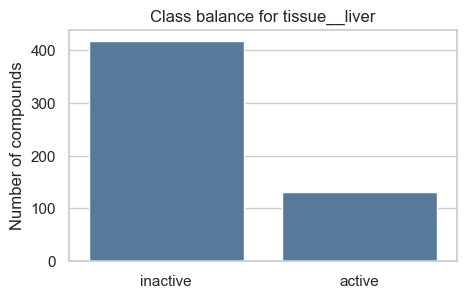

In [92]:
# Change this value to try a different prediction task.
TARGET = "tissue__liver"

if TARGET not in toxcast_assay_cols:
    raise ValueError(f"{TARGET} is not a valid ToxCast cell-based assay column.")

df_model = df_dl.dropna(subset=[TARGET]).copy()
X = df_model[feature_cols].copy()
y = df_model[TARGET].astype(int).copy()

class_balance = (
    y.value_counts()
    .rename(index={0: "inactive", 1: "active"})
    .rename_axis("class")
    .reset_index(name="n_compounds")
)
class_balance["fraction"] = class_balance["n_compounds"] / class_balance["n_compounds"].sum()

display(class_balance)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(data=class_balance, x="class", y="n_compounds", ax=ax, color="#4C78A8")
ax.set_title(f"Class balance for {TARGET}")
ax.set_xlabel("")
ax.set_ylabel("Number of compounds")
plt.show()

## 4. Train / validation / test splitting

The classical ML notebook used a train/test split. For deep learning, we also need a **validation set**.

- Training set: used to update neural-network weights.
- Validation set: used to compare parameter choices, detect overfitting, and choose a final model.
- Test set: held back until the end as an independent estimate of performance.

The test set is not used for model selection. That separation matters because neural networks have many settings to tune, and repeatedly checking the test set can leak information into the modelling process.

In [93]:
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAINING = 0.20

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=VALIDATION_SIZE_WITHIN_TRAINING,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

split_summary = pd.DataFrame(
    [
        {"split": "train", "n_compounds": len(y_train), "active_fraction": y_train.mean()},
        {"split": "validation", "n_compounds": len(y_val), "active_fraction": y_val.mean()},
        {"split": "test", "n_compounds": len(y_test), "active_fraction": y_test.mean()},
    ]
)

split_summary

,split,n_compounds,active_fraction
0,train,350,0.237143
1,validation,88,0.238636
2,test,110,0.236364


### Quick question

In one sentence: which set should we use to choose model settings, and which set should stay untouched until the end?

## 5. Feature preparation without data leakage

Neural networks usually train better when input features are on a similar scale. We will therefore:

1. Select the most variable Cell Painting features using the training set only.
2. Impute missing values using medians learned from the training set only.
3. Standardise features using means and standard deviations learned from the training set only.

We then apply those same transformations to the validation and test sets. This is the same anti-leakage idea used in classical machine learning.

In [ ]:
N_FEATURES = min(256, X_train.shape[1])

feature_variance = X_train.var(axis=0).sort_values(ascending=False)
selected_features = feature_variance.head(N_FEATURES).index.tolist()

scaler = StandardScaler()

X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]

X_train_scaled = scaler.fit_transform(X_train_selected).astype(np.float32)
X_val_scaled = scaler.transform(X_val_selected).astype(np.float32)
X_test_scaled = scaler.transform(X_test_selected).astype(np.float32)

y_train_array = y_train.to_numpy(dtype=np.float32)
y_val_array = y_val.to_numpy(dtype=np.float32)
y_test_array = y_test.to_numpy(dtype=np.float32)

print(f"Training compounds: {len(X_train_scaled):,}")
print(f"Validation compounds: {len(X_val_scaled):,}")
print(f"Test compounds: {len(X_test_scaled):,}")
print(f"Selected features: {len(selected_features):,}")

Training compounds: 350
Validation compounds: 88
Test compounds: 110
Selected features: 256


## 6. Convert arrays into tensors and data loaders

PyTorch models work with tensors. A `DataLoader` creates mini-batches, which means the model sees a small group of compounds at each weight update rather than the whole dataset at once.

The **batch size** is one of the parameters we will experiment with:

- Smaller batches make more noisy updates and can sometimes generalise better.
- Larger batches make smoother updates and can train faster per epoch.
- Very large batches may overfit or get stuck, especially with small datasets.

In [ ]:
def make_tensor_dataset(X_values, y_values):  # turn arrays into a PyTorch dataset
    X_tensor = torch.tensor(X_values, dtype=torch.float32)  # features
    y_tensor = torch.tensor(y_values, dtype=torch.float32).view(-1, 1)  # labels
    return TensorDataset(X_tensor, y_tensor)


train_dataset = make_tensor_dataset(X_train_scaled, y_train_array)
val_dataset = make_tensor_dataset(X_val_scaled, y_val_array)
test_dataset = make_tensor_dataset(X_test_scaled, y_test_array)



Example input batch shape: (32, 256)
Example target batch shape: (32, 1)


In [ ]:

def make_data_loader(dataset, batch_size=32, shuffle=False):  # make mini-batches
    generator = torch.Generator()  # controls random shuffling
    generator.manual_seed(RANDOM_STATE)  # make shuffling repeatable
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)


example_loader = make_data_loader(train_dataset, batch_size=32, shuffle=True)
example_X, example_y = next(iter(example_loader))

print(f"Example input batch shape: {tuple(example_X.shape)}")
print(f"Example target batch shape: {tuple(example_y.shape)}")

### Your turn

Run one or two commands to answer:

1. How many compounds are in `train_dataset`?
2. How many features does one compound have?

## Evaluation helpers

For this binary classification task, the neural network outputs one raw number called a **logit**. We convert logits into active-class scores with the sigmoid function. Scores near 1 indicate higher predicted activity; scores near 0 indicate lower predicted activity.

We will track several metrics because biological datasets are often imbalanced:

- Accuracy: fraction of correct predictions.
- Precision: among predicted actives, how many are truly active?
- Recall: among true actives, how many did we find?
- Balanced accuracy: average recall across the two classes.
- F1-score: harmonic mean of precision and recall.
- ROC AUC / AUROC: how well the model ranks active compounds above inactive compounds across thresholds.

In [96]:
def evaluate_scores(y_true, y_score, threshold=0.5, label="model"):  # calculate model metrics
    y_true = np.asarray(y_true).astype(int)  # true 0/1 labels
    y_score = np.asarray(y_score).reshape(-1)  # predicted activity scores
    y_pred = (y_score >= threshold).astype(int)  # convert scores to 0/1 predictions
    return pd.Series(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc_auroc": roc_auc_score(y_true, y_score) if pd.Series(y_true).nunique() == 2 else np.nan,
        },
        name=label,
    )


def predict_scores(model, loader):  # get predicted activity scores
    model.eval()  # use evaluation mode
    scores = []
    targets = []
    with torch.no_grad():  # skip gradient calculations during evaluation
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(DEVICE)
            logits = model(batch_X)
            batch_scores = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            scores.extend(batch_scores)
            targets.extend(batch_y.numpy().reshape(-1))
    return np.asarray(targets), np.asarray(scores)

## 7. Start with a simple reference

Before training the neural network, we create a majority-class reference. This asks: what happens if we ignore all Cell Painting features and always predict the most common training-set class?

A deep-learning model should do better than this reference. If it does not, the model may be overfitting, the target may be too difficult, or the input features may not contain enough information for this endpoint.

In [97]:
baseline_val_score = np.full(shape=len(y_val_array), fill_value=y_train_array.mean())
baseline_test_score = np.full(shape=len(y_test_array), fill_value=y_train_array.mean())

baseline_metrics = pd.concat(
    [
        evaluate_scores(y_val_array, baseline_val_score, label="Reference on validation"),
        evaluate_scores(y_test_array, baseline_test_score, label="Reference on test"),
    ],
    axis=1,
).T

baseline_metrics

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_auroc
Reference on validation,0.5,0.761364,0.5,0.0,0.0,0.0,0.5
Reference on test,0.5,0.763636,0.5,0.0,0.0,0.0,0.5


## 8. Build a simple neural network

A feed-forward neural network applies a sequence of transformations to the input features:

1. A linear layer combines the input features.
2. A nonlinear activation such as ReLU lets the model learn nonlinear patterns.
3. Dropout randomly hides some hidden units during training, which can reduce overfitting.
4. A final linear layer returns one logit for binary classification.

This is a **multilayer perceptron**, or MLP. It is simpler than a convolutional neural network because we are modelling extracted Cell Painting features rather than raw image pixels.

In [98]:
class CellPaintingMLP(nn.Module):  # small feed-forward neural network
    def __init__(self, n_inputs, hidden_units=(128, 64), dropout=0.25):  # build the layers
        super().__init__()
        layers = []
        previous_units = n_inputs

        for units in hidden_units:
            layers.append(nn.Linear(previous_units, units))  # combine inputs
            layers.append(nn.ReLU())  # add nonlinearity
            if dropout > 0:
                layers.append(nn.Dropout(p=dropout))  # reduce overfitting
            previous_units = units

        layers.append(nn.Linear(previous_units, 1))  # output one logit
        self.network = nn.Sequential(*layers)  # run layers in order

    def forward(self, x):  # make one prediction pass
        return self.network(x)


example_model = CellPaintingMLP(
    n_inputs=X_train_scaled.shape[1],
    hidden_units=(128, 64),
    dropout=0.25,
)

example_model

CellPaintingMLP(
  (network): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

### Simple check

1. How many input features go into `example_model`?

2. How many hidden layers does `example_model` have?

3. What does the final `Linear(..., 1)` layer predict?

4. Which layer uses dropout?

## Loss functions

The loss function is the signal the model tries to minimise.

For binary classification with one output logit, `BCEWithLogitsLoss` is the standard PyTorch choice. It combines a sigmoid transformation with binary cross-entropy in a numerically stable way.

We will compare three options:

- `bce`: standard binary cross-entropy.
- `weighted_bce`: binary cross-entropy with extra weight on the active class.
- `focal`: a focal loss that puts more emphasis on examples the model currently finds hard.

Weighted or focal losses can be useful when active compounds are rare.

In [99]:
def make_loss_function(loss_choice, y_train_values):
    """
    Available options:

    1. "bce"
       Standard Binary Cross Entropy.
       Use when classes are reasonably balanced.

    2. "weighted_bce"
       Gives extra importance to positive (active) compounds.
       Useful when positives are rare.

    3. "focal"
       Focuses learning on difficult examples.
       Useful for highly imbalanced datasets.
    """

    loss_choice = loss_choice.lower()

    if loss_choice == "bce":
        return nn.BCEWithLogitsLoss()

    elif loss_choice == "weighted_bce":
        n_positive = np.sum(y_train_values == 1)
        n_negative = np.sum(y_train_values == 0)

        pos_weight = torch.tensor(
            [n_negative / max(n_positive, 1)],
            dtype=torch.float32,
            device=DEVICE
        )

        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    elif loss_choice == "focal":
        return BinaryFocalLoss(
            alpha=0.35,
            gamma=2.0
        )

    else:
        raise ValueError(
            "Choose one of: 'bce', 'weighted_bce', or 'focal'."
        )

## Training helpers

The training loop has two phases in each epoch:

- Training phase: update model weights using mini-batches from the training set.
- Validation phase: calculate loss and metrics without updating weights.

An **epoch** is one full pass through the training set. More epochs mean more opportunities to learn, but too many epochs can make the model memorise the training data.

In [100]:
def run_one_epoch(model, loader, loss_function, optimizer=None):
    is_training = optimizer is not None
    model.train(mode=is_training)
    total_loss = 0.0
    n_examples = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        if is_training:
            optimizer.zero_grad()

        logits = model(batch_X)
        loss = loss_function(logits, batch_y)

        if is_training:
            loss.backward()
            optimizer.step()

        batch_size = batch_X.shape[0]
        total_loss += loss.item() * batch_size
        n_examples += batch_size

    return total_loss / n_examples


def train_neural_network(
    hidden_units=(128, 64),
    dropout=0.25,
    batch_size=32,
    n_epochs=80,
    learning_rate=1e-3,
    weight_decay=1e-4,
    loss_choice="weighted_bce",
    verbose=True,
):
    torch.manual_seed(RANDOM_STATE)

    train_loader = make_data_loader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = make_data_loader(val_dataset, batch_size=batch_size, shuffle=False)

    model = CellPaintingMLP(
        n_inputs=X_train_scaled.shape[1],
        hidden_units=hidden_units,
        dropout=dropout,
    ).to(DEVICE)

    loss_function = make_loss_function(loss_choice, y_train_array)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    history = []
    best_state = None
    best_val_loss = np.inf

    for epoch in range(1, n_epochs + 1):
        train_loss = run_one_epoch(model, train_loader, loss_function, optimizer=optimizer)
        with torch.no_grad():
            val_loss = run_one_epoch(model, val_loader, loss_function, optimizer=None)

        val_targets, val_scores = predict_scores(model, val_loader)
        val_metrics = evaluate_scores(val_targets, val_scores, label="validation")

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_roc_auc_auroc": val_metrics["roc_auc_auroc"],
            }
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

        if verbose and (epoch == 1 or epoch % 10 == 0 or epoch == n_epochs):
            print(
                f"Epoch {epoch:03d} | train loss {train_loss:.4f} | "
                f"validation loss {val_loss:.4f} | validation AUROC {val_metrics['roc_auc_auroc']:.3f}"
            )

    if best_state is not None:
        model.load_state_dict({key: value.to(DEVICE) for key, value in best_state.items()})

    history_df = pd.DataFrame(history)
    return model, history_df

## 9. Train a first neural network

The settings below are deliberately small enough for a teaching notebook. They are not magic values. We will change them in the next section.

In [101]:
first_model, first_history = train_neural_network(
    hidden_units=(128, 64),
    dropout=0.25,
    batch_size=32,
    n_epochs=80,
    learning_rate=1e-3,
    weight_decay=1e-4,
    loss_choice="weighted_bce",
)

first_history.tail()

Epoch 001 | train loss 1.0084 | validation loss 0.9948 | validation AUROC 0.808
Epoch 010 | train loss 0.4797 | validation loss 0.8471 | validation AUROC 0.844
Epoch 020 | train loss 0.1044 | validation loss 1.3256 | validation AUROC 0.834
Epoch 030 | train loss 0.0205 | validation loss 1.8491 | validation AUROC 0.843
Epoch 040 | train loss 0.0068 | validation loss 2.2006 | validation AUROC 0.827
Epoch 050 | train loss 0.0048 | validation loss 2.4766 | validation AUROC 0.827
Epoch 060 | train loss 0.0078 | validation loss 2.3920 | validation AUROC 0.832
Epoch 070 | train loss 0.0028 | validation loss 2.4960 | validation AUROC 0.830
Epoch 080 | train loss 0.0017 | validation loss 2.7002 | validation AUROC 0.822


,epoch,train_loss,val_loss,val_accuracy,val_balanced_accuracy,val_roc_auc_auroc
75,76,0.002935,2.677877,0.784091,0.662047,0.808102
76,77,0.002905,2.754520,0.806818,0.676972,0.818763
77,78,0.004145,2.745695,0.795455,0.669510,0.819474
78,79,0.002528,2.752617,0.818182,0.717129,0.823738
79,80,0.001739,2.700151,0.818182,0.717129,0.822317


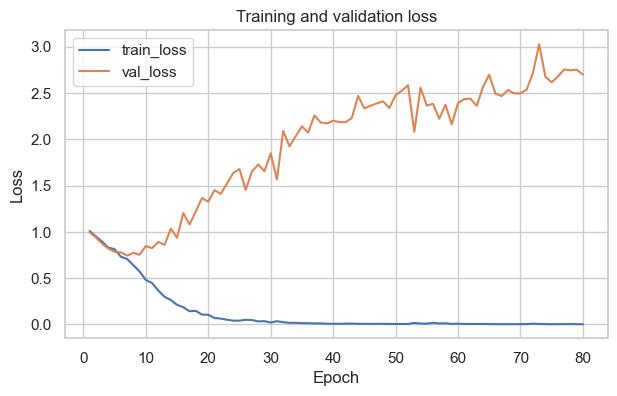

In [102]:
fig, ax = plt.subplots(figsize=(7, 4))
first_history.plot(x="epoch", y=["train_loss", "val_loss"], ax=ax)
ax.set_title("Training and validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.show()

### Reading the loss curves

- If training loss decreases but validation loss increases, the model is probably overfitting.
- If both losses stay high, the model may be underfitting or the learning rate may be too small.
- If losses jump around, the learning rate may be too large or the batch size may be too small.
- If validation loss improves and then plateaus, more epochs may not help much.

In real projects, early stopping is often used to stop training when validation loss no longer improves. Here, the helper function keeps the weights from the epoch with the best validation loss.

In [103]:
val_loader = make_data_loader(val_dataset, batch_size=64, shuffle=False)
val_targets, first_val_scores = predict_scores(first_model, val_loader)

pd.concat(
    [
        evaluate_scores(y_val_array, baseline_val_score, label="Reference"),
        evaluate_scores(val_targets, first_val_scores, label="First neural network"),
    ],
    axis=1,
).T

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_auroc
Reference,0.5,0.761364,0.500000,0.000000,0.000000,0.00,0.500000
First neural network,0.5,0.795455,0.783937,0.551724,0.761905,0.64,0.847193


## 10. Your turn: change the model parameters

Try changing the values below, then re-run the next few cells.

Parameters to experiment with:

- `PLAY_DROPOUT`: try `0.0`, `0.25`, `0.5`.
- `PLAY_BATCH_SIZE`: try `16`, `32`, `64`, `128`.
- `PLAY_N_EPOCHS`: try `20`, `80`, `150`.
- `PLAY_LOSS_CHOICE`: try `"bce"`, `"weighted_bce"`, `"focal"`.
- `PLAY_HIDDEN_UNITS`: try `(64,)`, `(128, 64)`, `(256, 128, 64)`.
- `PLAY_LEARNING_RATE`: try `1e-4`, `1e-3`, `3e-3`.

Guiding questions:

- Does dropout reduce the gap between training and validation loss?
- Does changing the batch size make training smoother or noisier?
- Do more epochs always improve validation loss?
- Does a weighted loss improve recall for active compounds?
- Which setting would you choose before looking at the test set?

In [104]:
PLAY_HIDDEN_UNITS = (128, 64)
PLAY_DROPOUT = 0.6
PLAY_BATCH_SIZE = 32
PLAY_N_EPOCHS = 20
PLAY_LEARNING_RATE = 1e-3
PLAY_WEIGHT_DECAY = 1e-4
PLAY_LOSS_CHOICE = "weighted_bce"

student_model, student_history = train_neural_network(
    hidden_units=PLAY_HIDDEN_UNITS,
    dropout=PLAY_DROPOUT,
    batch_size=PLAY_BATCH_SIZE,
    n_epochs=PLAY_N_EPOCHS,
    learning_rate=PLAY_LEARNING_RATE,
    weight_decay=PLAY_WEIGHT_DECAY,
    loss_choice=PLAY_LOSS_CHOICE,
)

student_history.tail()

Epoch 001 | train loss 1.0278 | validation loss 1.0240 | validation AUROC 0.760
Epoch 010 | train loss 0.7668 | validation loss 0.7654 | validation AUROC 0.848
Epoch 020 | train loss 0.4922 | validation loss 0.8245 | validation AUROC 0.858


,epoch,train_loss,val_loss,val_accuracy,val_balanced_accuracy,val_roc_auc_auroc
15,16,0.587325,0.741003,0.795455,0.734897,0.858564
16,17,0.584155,0.793485,0.818182,0.749822,0.864250
17,18,0.519018,0.788010,0.818182,0.749822,0.859275
18,19,0.496637,0.762332,0.784091,0.727434,0.856432
19,20,0.492166,0.824518,0.818182,0.749822,0.857854


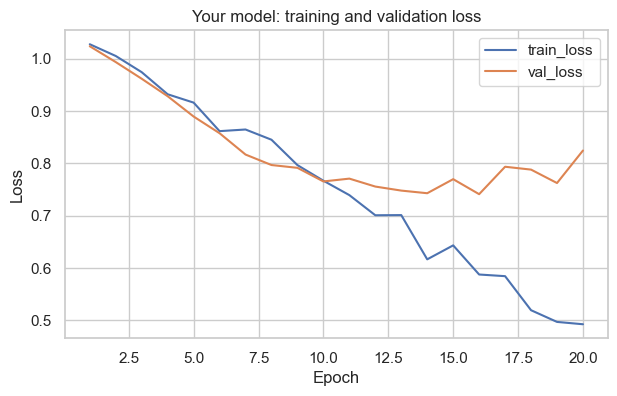

,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_auroc
First neural network,0.5,0.795455,0.783937,0.551724,0.761905,0.640000,0.847193
Your parameter choice,0.5,0.795455,0.734897,0.565217,0.619048,0.590909,0.858564


In [105]:
fig, ax = plt.subplots(figsize=(7, 4))
student_history.plot(x="epoch", y=["train_loss", "val_loss"], ax=ax)
ax.set_title("Your model: training and validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.show()

student_val_targets, student_val_scores = predict_scores(student_model, val_loader)

pd.concat(
    [
        evaluate_scores(val_targets, first_val_scores, label="First neural network"),
        evaluate_scores(student_val_targets, student_val_scores, label="Your parameter choice"),
    ],
    axis=1,
).T

## 11. Compare a small set of experiments

Manual experimentation is useful for intuition. We can also define a small list of experiments and compare them consistently on the validation set.

This is intentionally small. Deep-learning searches can become expensive quickly, and the validation set should guide model selection before the test set is opened.

Because these experiments can use different loss functions, raw loss values are not always directly comparable across experiments. Use loss curves to understand training behaviour, and use a shared validation metric such as AUROC or balanced accuracy to choose between different loss functions.

In [106]:
experiment_configs = [
    {
        "name": "small_no_dropout_bce",
        "hidden_units": (64,),
        "dropout": 0.0,
        "batch_size": 32,
        "n_epochs": 60,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "loss_choice": "bce",
    },
    {
        "name": "medium_dropout_weighted",
        "hidden_units": (128, 64),
        "dropout": 0.25,
        "batch_size": 32,
        "n_epochs": 60,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "loss_choice": "weighted_bce",
    },
    {
        "name": "large_dropout_focal",
        "hidden_units": (256, 128, 64),
        "dropout": 0.5,
        "batch_size": 64,
        "n_epochs": 60,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "loss_choice": "focal",
    },
]

experiment_models = {}
experiment_histories = {}
experiment_rows = []

for config in experiment_configs:
    print(f"\nTraining {config['name']}")
    model, history = train_neural_network(
        hidden_units=config["hidden_units"],
        dropout=config["dropout"],
        batch_size=config["batch_size"],
        n_epochs=config["n_epochs"],
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
        loss_choice=config["loss_choice"],
        verbose=False,
    )

    experiment_models[config["name"]] = model
    experiment_histories[config["name"]] = history

    val_targets_tmp, val_scores_tmp = predict_scores(model, val_loader)
    metrics = evaluate_scores(val_targets_tmp, val_scores_tmp, label=config["name"])

    row = {
        "name": config["name"],
        "hidden_units": str(config["hidden_units"]),
        "dropout": config["dropout"],
        "batch_size": config["batch_size"],
        "n_epochs": config["n_epochs"],
        "loss_choice": config["loss_choice"],
        "best_val_loss": history["val_loss"].min(),
        "final_train_loss": history["train_loss"].iloc[-1],
        "final_val_loss": history["val_loss"].iloc[-1],
        "val_roc_auc_auroc": metrics["roc_auc_auroc"],
        "val_balanced_accuracy": metrics["balanced_accuracy"],
        "val_precision": metrics["precision"],
        "val_recall": metrics["recall"],
    }
    experiment_rows.append(row)

experiment_results = pd.DataFrame(experiment_rows).sort_values(
    ["val_roc_auc_auroc", "val_balanced_accuracy"], ascending=[False, False]
)

experiment_results


Training small_no_dropout_bce

Training medium_dropout_weighted

Training large_dropout_focal


,name,hidden_units,dropout,batch_size,n_epochs,loss_choice,best_val_loss,final_train_loss,final_val_loss,val_roc_auc_auroc,val_balanced_accuracy,val_precision,val_recall
2,large_dropout_focal,"(256, 128, 64)",0.50,64,60,focal,0.044104,0.014474,0.158089,0.880597,0.547619,1.000000,0.095238
0,small_no_dropout_bce,"(64,)",0.00,32,60,bce,0.370193,0.026848,0.524356,0.872779,0.715707,0.769231,0.476190
1,medium_dropout_weighted,"(128, 64)",0.25,32,60,weighted_bce,0.743367,0.007827,2.391996,0.847193,0.783937,0.551724,0.761905


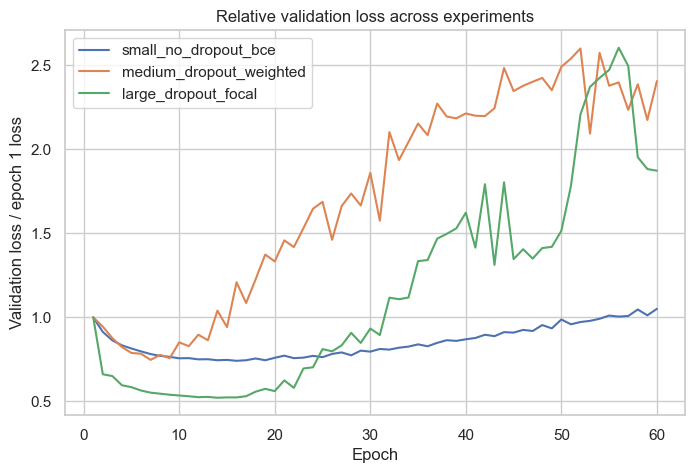

In [107]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, history in experiment_histories.items():
    relative_val_loss = history["val_loss"] / history["val_loss"].iloc[0]
    ax.plot(history["epoch"], relative_val_loss, label=name)

ax.set_title("Relative validation loss across experiments")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss / epoch 1 loss")
ax.legend()
plt.show()

### Quick question

Which experiment would you choose using validation data only? 

## 12. Independent test-set evaluation

Now we open the held-out test set. This should happen once, after choosing model settings with the validation set.

In the code below, the selected model is the experiment with the highest validation AUROC. You could choose a different validation-based rule, such as highest recall, but make that decision before checking the test metrics.

In [108]:
best_experiment_name = experiment_results.iloc[0]["name"]
best_model = experiment_models[best_experiment_name]

test_loader = make_data_loader(test_dataset, batch_size=64, shuffle=False)
test_targets, test_scores = predict_scores(best_model, test_loader)

final_metrics = pd.concat(
    [
        evaluate_scores(y_test_array, baseline_test_score, label="Reference"),
        evaluate_scores(test_targets, test_scores, label=f"Best neural network: {best_experiment_name}"),
    ],
    axis=1,
).T

print(f"Selected experiment: {best_experiment_name}")
final_metrics

Selected experiment: large_dropout_focal


,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc_auroc
Reference,0.5,0.763636,0.500000,0.000000,0.000000,0.00,0.500000
Best neural network: large_dropout_focal,0.5,0.781818,0.565018,0.666667,0.153846,0.25,0.750458


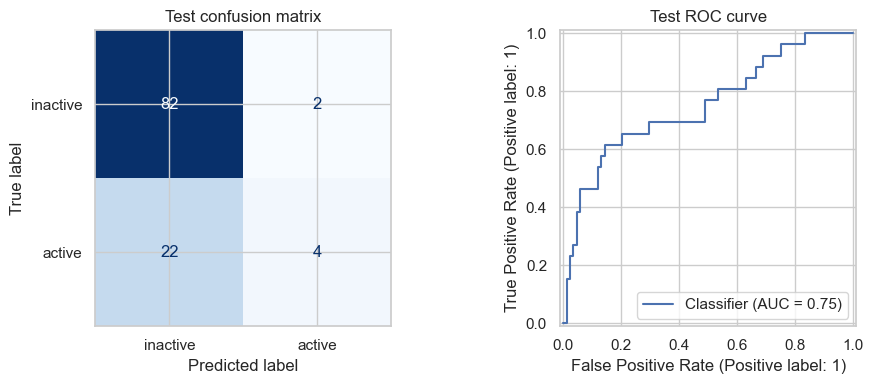

In [109]:
test_pred = (test_scores >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    test_targets,
    test_pred,
    display_labels=["inactive", "active"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Test confusion matrix")

RocCurveDisplay.from_predictions(test_targets, test_scores, ax=axes[1])
axes[1].set_title("Test ROC curve")

plt.tight_layout()
plt.show()

## 13. Inspect high-scoring compounds

A model evaluation table tells us about aggregate performance. It is also useful to inspect individual compounds with high predicted activity scores.

Questions to ask:

- Are the highest-scoring compounds true actives, false positives, or a mix?
- Do these compounds share known mechanisms or chemical classes?
- What extra biological information would help decide whether the model learned a meaningful image-derived signal?

In [114]:
compound_columns = [
    col
    for col in [
        "Metadata_compound",
        "OASIS_ID",
        "Metadata_compound_target",
        "Metadata_compound_pathway",
    ]
    if col in df_model.columns
]

prediction_table = df_model.loc[X_test.index, compound_columns].copy()
prediction_table["true_label"] = y_test_array.astype(int)
prediction_table["predicted_activity_score"] = test_scores
prediction_table["predicted_label_0_5"] = (test_scores >= 0.5).astype(int)

prediction_table.sort_values("predicted_activity_score", ascending=False).head(15)

,Metadata_compound,OASIS_ID,Metadata_compound_target,Metadata_compound_pathway,true_label,predicted_activity_score,predicted_label_0_5
406,Plicamycin,OASIS1215,Antibiotic; Bacterial; DNA/RNA Synthesis; Glut...,Anti-infection; Cell Cycle/DNA Damage; Metabol...,0,0.999393,1
103,Carfilzomib,OASIS1817,Apoptosis; Autophagy; Proteasome,Apoptosis; Autophagy; Metabolic Enzyme/Protease,1,0.847047,1
452,Romidepsin,OASIS1486,Apoptosis; HDAC,Apoptosis; Cell Cycle/DNA Damage; Epigenetics,1,0.676271,1
366,Nocodazole,OASIS1560,Apoptosis; Autophagy; Bcr-Abl; CRISPR/Cas9; Mi...,Apoptosis; Autophagy; Cell Cycle/DNA Damage; C...,1,0.520570,1
382,Paclitaxel,OASIS1549,ADC Cytotoxin; Apoptosis; Autophagy; Microtubu...,Antibody-drug Conjugate/ADC Related; Apoptosis...,1,0.506613,1
130,Cladribine,OASIS1402,Adenosine Deaminase; Apoptosis,Apoptosis; Metabolic Enzyme/Protease,0,0.504397,1
245,Gefitinib,OASIS1455,Apoptosis; Autophagy; EGFR,Apoptosis; Autophagy; JAK/STAT Signaling; Prot...,1,0.493113,0
497,Terfenadine,OASIS822,Apoptosis; Caspase; Histamine Receptor; Na+/Ca...,Apoptosis; GPCR/G Protein; Immunology/Inflamma...,1,0.488763,0
59,Azithromycin,OASIS1450,Antibiotic; Autophagy; Bacterial; Parasite,Anti-infection; Autophagy,0,0.486971,0
480,Suloctidil,OASIS1050,Na+/K+ ATPase,Membrane Transporter/Ion Channel,1,0.486508,0


## Bonus: retrain on training + validation data

For a real final model, it is common to choose parameters using validation data, then retrain with both training and validation data before predicting the test set or future unseen data.

That makes the training dataset larger, but the test set must still stay untouched until the final evaluation. This section is optional because it repeats the same workflow with slightly more data.

## Final reflection

Write a short answer to each prompt:

- Did the neural network predict your selected assay better than the reference model?
- Did the model overfit, underfit, or train reasonably? What evidence from the loss curves supports your answer?
- Which parameter changed performance the most: dropout, batch size, epochs, hidden units, learning rate, or loss function?
- Did the validation performance match the independent test performance?
- What would you try next for bioimaging data: more compounds, a different target, raw-image CNNs, stronger regularisation, or biological grouping of train/test splits?